# Controlled Invariant Set


In this example, we compute the maximal (resp. minimal) controlled invariant
set contained in the square with vertices $(\pm 1, \pm 1)$ for the system
$$
\begin{aligned}
v_{k+1} & = v_k + a_k \Delta t\\
a_{k+1} & = u_k
\end{aligned}
$$
using the technique developed in [LTJ18].

The system is $x_{k+1} = A x_k + B u_k$ where $B = (0, 1)$ and
$$
A = \begin{bmatrix}
1 & \Delta t\\
0 & 0
\end{bmatrix}.
$$
As shown in [LTJ18], a set $S$ is controlled invariant if
$$
\begin{bmatrix}
1 & \Delta t
\end{bmatrix} S
\subseteq
\begin{bmatrix}
1 & 0
\end{bmatrix} S.
$$

[LTJ18] B. Legat, P. Tabuada and R. M. Jungers.
*Computing controlled invariant sets for hybrid systems with applications to model-predictive control*.
6th IFAC Conference on Analysis and Design of Hybrid Systems ADHS 2018, **2018**.

In [1]:
using Polyhedra
h = HalfSpace([1, 0], 1.0) ∩ HalfSpace([-1, 0], 1) ∩ HalfSpace([0, 1], 1) ∩ HalfSpace([0, -1], 1)
□ = polyhedron(h)

Polyhedron DefaultPolyhedron{Float64, Polyhedra.Intersection{Float64, Vector{Float64}, Int64}, Polyhedra.Hull{Float64, Vector{Float64}, Int64}}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([1.0, 0.0], 1.0)
 HalfSpace([-1.0, 0.0], 1.0)
 HalfSpace([0.0, 1.0], 1.0)
 HalfSpace([0.0, -1.0], 1.0)

We need to pick an SDP solver, see
[here](https://jump.dev/JuMP.jl/stable/installation/#Supported-solvers)
for a list of available ones.

In [2]:
using SetProg
import CSDP
sdp_solver = optimizer_with_attributes(CSDP.Optimizer, MOI.Silent() => true)

Δt = 0.5
A = [1.0 Δt]
E = [1.0 0.0]

1×2 Matrix{Float64}:
 1.0  0.0

## Ellipsoidal template

We first look for the largest controlled invariant ellipsoid contained in the
square.

In [3]:
model = Model(sdp_solver)
@variable(model, S, Ellipsoid(symmetric=true))
@constraint(model, S ⊆ □)
@constraint(model, A * S ⊆ E * S)
@objective(model, Max, nth_root(volume(S)))
optimize!(model)
@show solve_time(model)
@show termination_status(model)
@show objective_value(model)
ell = value(S)

solve_time(model) = 0.004519224166870117
termination_status(model) = OPTIMAL
objective_value(model) = 0.9682458357350057


SetProg.Sets.Polar{Float64, SetProg.Sets.Ellipsoid{Float64}}(SetProg.Sets.Ellipsoid{Float64}([0.9999999996484527 -0.2500000002510654; -0.2500000002510654 0.999999999598224]))

## Polynomial sublevel sets

To allow for tighter approximations, we now use sublevel sets of polynomials
of degree $d$. The `L1_heuristic` objective is a tractable proxy for the
volume; see Section 4.2 of [L20] for details.

[L20] Legat, B. (2020). *Set programming : theory and computation*. Ph.D. thesis, UCLouvain.

In [4]:
function Sd(d)
    model = Model(sdp_solver)
    @variable(model, S, PolySet(degree=d, convex=true, symmetric=true))
    @constraint(model, S ⊆ □)
    @constraint(model, A * S ⊆ E * S)
    @objective(model, Max, L1_heuristic(volume(S), [1.0, 1.0]))
    optimize!(model)
    @show solve_time(model)
    @show termination_status(model)
    @show objective_value(model)
    return value(S)
end

Sd (generic function with 1 method)

We compute the maximal controlled invariant sublevel set for several degrees.

In [5]:
S4 = Sd(4)
S8 = Sd(8)
S12 = Sd(12)
S16 = Sd(16)
S20 = Sd(20)
S22 = Sd(22)

solve_time(model) = 0.002485036849975586
termination_status(model) = OPTIMAL
objective_value(model) = 0.39999999806931175
solve_time(model) = 0.004210948944091797
termination_status(model) = OPTIMAL
objective_value(model) = 0.22296014236268924
solve_time(model) = 0.008061885833740234
termination_status(model) = OPTIMAL
objective_value(model) = 0.15411326088807173
solve_time(model) = 0.030100107192993164
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.11775235777427202
solve_time(model) = 0.05624794960021973
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.06893260083625613
solve_time(model) = 0.056104183197021484
termination_status(model) = ALMOST_OPTIMAL
objective_value(model) = 0.022604959289143252


SetProg.Sets.Polar{Float64, SetProg.Sets.ConvexPolySet{Float64, StarAlgebras.SubBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Int64, Vector{Int64}, StarAlgebras.MappedBasis{MultivariateBases.Polynomial{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}, Vector{Int64}}, Vector{Int64}, MultivariatePolynomials.ExponentsIterator{MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}, Nothing, Vector{Int64}}, MultivariateBases.Variables{Monomial, Vector{DynamicPolynomials.Variable{DynamicPolynomials.Commutative{DynamicPolynomials.CreationOrder}, MultivariatePolynomials.Graded{MultivariatePolynomials.LexOrder}}}}, typeof(MultivariatePolynomials.exponents)}, Vector{Vector{Int64

## Plotting

Below are reference polytopes used in the plots: the maximal controlled
invariant polytope `mci` and its polar.

In [6]:
mci = □ ∩ HalfSpace([1.0, 0.5], 1.0) ∩ HalfSpace([-1.0, -0.5], 1.0)
polar_□ = polar(□)
polar_mci = polar(mci)

Polyhedron DefaultPolyhedron{Float64, Polyhedra.Intersection{Float64, Vector{Float64}, Int64}, Polyhedra.Hull{Float64, Vector{Float64}, Int64}}:
6-element iterator of Vector{Float64}:
 [1.0, 0.0]
 [-1.0, 0.0]
 [0.0, 1.0]
 [0.0, -1.0]
 [1.0, 0.5]
 [-1.0, -0.5]

We plot the polynomial sublevel sets together with the square and `mci`.

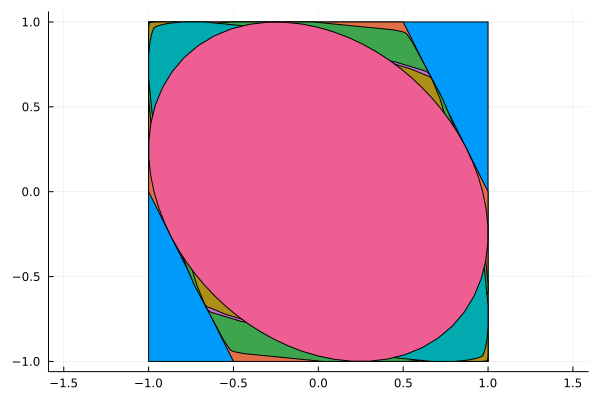

In [7]:
using Plots
plot(ratio=:equal)
plot!(□)
plot!(mci)
plot!(S22)
plot!(S16)
plot!(S8)
plot!(S4)
plot!(ell)

And the corresponding polar plot:

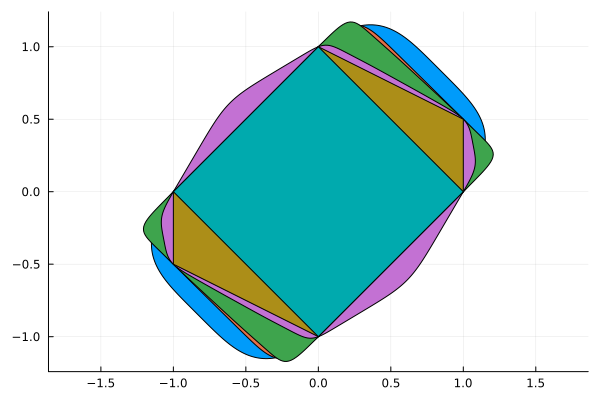

In [8]:
plot(ratio=:equal)
plot!(SetProg.Sets.polar(S4); npoints=512)
plot!(SetProg.Sets.polar(S8); npoints=512)
plot!(SetProg.Sets.polar(S16); npoints=512)
plot!(SetProg.Sets.polar(S22); npoints=512)
plot!(polar_mci)
plot!(polar_□)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*